In [37]:
#Realizando as importações das bibliotecas
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os

warnings.filterwarnings('ignore')

In [38]:
#Download da versão recente do kaggle
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Path to dataset files: /kaggle/input/superstore-dataset-final


In [39]:
# Definindo um padrão visual para os gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [40]:
#Importando o dataset
arquivo_csv = os.path.join(path, 'Sample - Superstore.csv')

In [41]:
#Definindo idioma e formato de leitura da coluna 'Postal Code'
df = pd.read_csv(arquivo_csv, encoding='latin-1', dtype={'Postal Code': str})

In [42]:
#Conferindo importação, visualizando as primeiras linhas
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [43]:
#Informações gerais do Dataset: nulos e classificação das colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   object 
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [44]:
#Realizando a tradução e padronização do Dataset

#Colunas
traducao_colunas = {
    'Row ID': 'id_linha',
    'Order ID': 'id_pedido',
    'Order Date': 'data_pedido',
    'Ship Date': 'data_envio',
    'Ship Mode': 'modo_envio',
    'Customer ID': 'id_cliente',
    'Customer Name': 'nome_cliente',
    'Segment': 'segmento',
    'Country': 'pais',
    'City': 'cidade',
    'State': 'estado',
    'Postal Code': 'codigo_postal',
    'Region': 'regiao',
    'Product ID': 'id_produto',
    'Category': 'categoria',
    'Sub-Category': 'subcategoria',
    'Product Name': 'nome_produto',
    'Sales': 'vendas',
    'Quantity': 'quantidade',
    'Discount': 'desconto',
    'Profit': 'lucro'
}

df.rename(columns=traducao_colunas, inplace=True)

#Categorias
traducao_categoria = {
    'Furniture': 'Móveis',
    'Office Supplies': 'Materiais de Escritório',
    'Technology': 'Tecnologia'
}

df['categoria'] = df['categoria'].replace(traducao_categoria)

#Segmentos
traducao_segmento = {
    'Consumer': 'Consumidor',
    'Corporate': 'Corporativo',
    'Home Office': 'Home Office'
}

df['segmento'] = df['segmento'].replace(traducao_segmento)

#Regiões
traducao_regiao = {
    'South': 'Sul',
    'West': 'Oeste',
    'Central': 'Central',
    'East': 'Leste'
}

df['regiao'] = df['regiao'].replace(traducao_regiao)

#Métodos de envio
traducao_envio = {
    'First Class': 'Primeira Classe',
    'Second Class': 'Segunda Classe',
    'Standard Class': 'Classe Padrão',
    'Same Day': 'Mesmo Dia'
}

df['modo_envio'] = df['modo_envio'].replace(traducao_envio)


In [45]:
#Tratamento e limpeza de dados

# Verificando a quantidade e o percentual de valores nulos por coluna
nulos = pd.DataFrame({
    'Quantidade': df.isnull().sum(),
    'Percentual (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

# Exibe apenas as colunas que têm pelo menos 1 valor nulo
nulos_existentes = nulos[nulos['Quantidade'] > 0]

if nulos_existentes.empty:
    print('Nenhum valor nulo encontrado!')
else:
    print('Colunas com valores nulos:')
    display(nulos_existentes)

#Verificando se dataframe possui dados duplicados no arquivo geral.
qtd_duplicatas = df.duplicated().sum()
print(f'Total de linhas duplicadas encontradas: {qtd_duplicatas}')

#Convertendo Datas
df['data_pedido'] = pd.to_datetime(df['data_pedido'])
df['data_envio'] = pd.to_datetime(df['data_envio'])

#Verificar tipos de dados
df.dtypes


Nenhum valor nulo encontrado!
Total de linhas duplicadas encontradas: 0


,0
id_linha,int64
id_pedido,object
data_pedido,datetime64[ns]
data_envio,datetime64[ns]
modo_envio,object
id_cliente,object
nome_cliente,object
segmento,object
pais,object
cidade,object


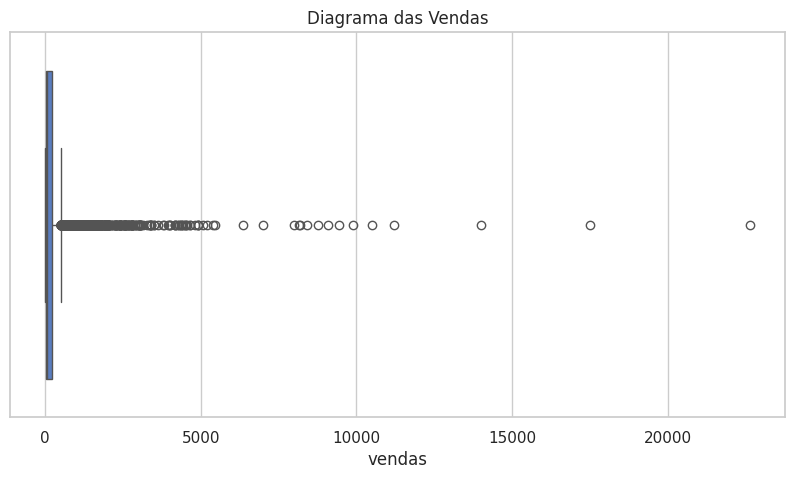

Limite superior (IQR): $498.93
Outliers encontrados : 1167 (11.7% da base)



,total_pedidos,venda_media,lucro_medio,margem_media,desconto_medio,entrega_media
grupo,,,,,,
Outliers (alto valor),1167,1266.05,160.71,9.87,0.15,3.89
Pedidos normais,8827,92.86,11.20,12.32,0.16,3.97


In [46]:
#Tratamento de Outliers

plt.figure(figsize=(10,5))

sns.boxplot(x=df['vendas'])

plt.title('Diagrama das Vendas')

plt.show()

#Identificação de Outliers
Q1 = df['vendas'].quantile(0.25)
Q3 = df['vendas'].quantile(0.75)
IQR = Q3 - Q1
limite_sup = Q3 + 1.5 * IQR

outliers = df[df['vendas'] > limite_sup]

print(f'Limite superior (IQR): ${limite_sup:.2f}')
print(f'Outliers encontrados : {len(outliers)} ({len(outliers)/len(df)*100:.1f}% da base)')
print()

# Criando as colunas 'dias_entrega' e 'margem_lucro' antes de usá-las
df['dias_entrega'] = (df['data_envio'] - df['data_pedido']).dt.days
df['margem_lucro'] = (df['lucro'] / df['vendas']) * 100

# Comparativo: outliers vs restante da base
comparativo = (
    df.assign(grupo=df['vendas'].gt(limite_sup)
              .map({False: 'Pedidos normais', True: 'Outliers (alto valor)'}))
    .groupby('grupo')
    .agg(
        total_pedidos  = ('id_pedido',    'count'),
        venda_media    = ('vendas',       'mean'),
        lucro_medio    = ('lucro',        'mean'),
        margem_media   = ('margem_lucro', 'mean'),
        desconto_medio = ('desconto',     'mean'),
        entrega_media  = ('dias_entrega', 'mean')
    )
    .round(2)
)

display(comparativo)

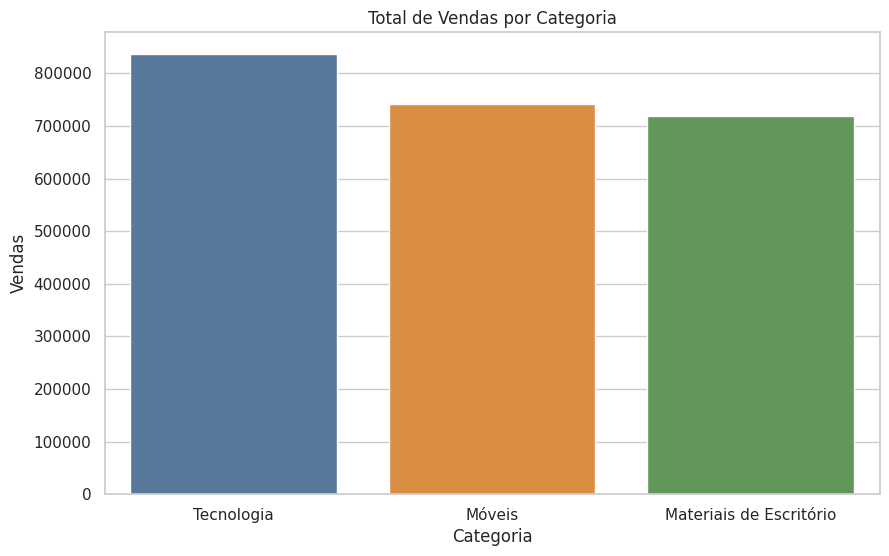

Conclusão: A categoria com maior volume de vendas demonstra maior participação no faturamento da empresa. Isso pode indicar maior demanda do mercado por esse tipo de produto.


In [47]:
#Total de vendas por categoria
categoria_vendas = df.groupby('categoria')['vendas'].sum().sort_values(ascending=False)

# Criando o gráfico de barras com cores personalizadas
plt.figure(figsize=(10, 6))
sns.barplot(x=categoria_vendas.index, y=categoria_vendas.values, palette=['#4e79a7', '#f28e2b', '#59a14f'])

plt.title('Total de Vendas por Categoria')
plt.xlabel('Categoria')
plt.xticks(rotation=0) # Mantém os rótulos na horizontal
plt.ylabel('Vendas')

plt.show()
print('Conclusão: A categoria com maior volume de vendas demonstra maior participação no faturamento da empresa. Isso pode indicar maior demanda do mercado por esse tipo de produto.')

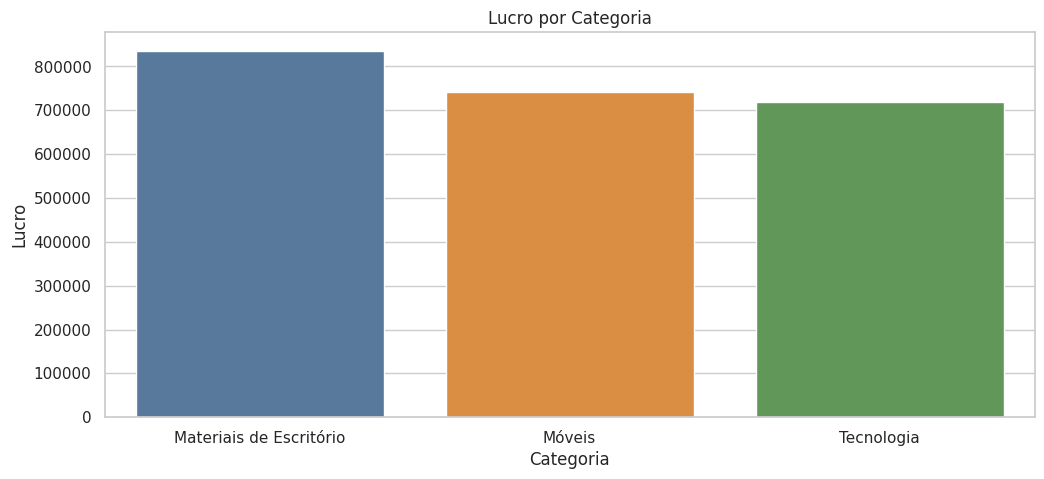

Conclusão: Nem sempre a categoria que mais vende é a mais lucrativa. Essa análise ajuda a identificar quais categorias geram maior retorno financeiro para a empresa.


In [48]:
#Calculando o lucro por categoria
lucro_categoria = df.groupby('categoria')['lucro'].sum()

lucro_categoria.plot(kind='bar', color='green')
sns.barplot(x=categoria_vendas.index, y=categoria_vendas.values, palette=['#4e79a7', '#f28e2b', '#59a14f'])
plt.title('Lucro por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Lucro')
plt.xticks(rotation=0)

plt.show()
print('Conclusão: Nem sempre a categoria que mais vende é a mais lucrativa. Essa análise ajuda a identificar quais categorias geram maior retorno financeiro para a empresa.')

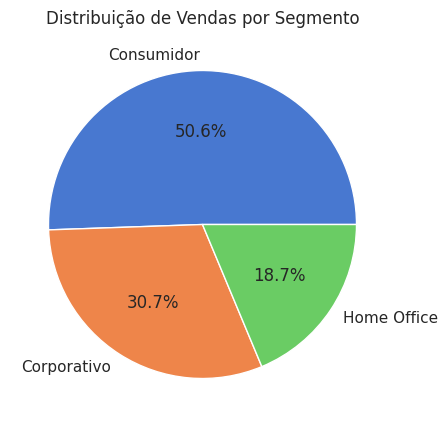

In [49]:
#Vendas por Segmento
segmento_vendas = df.groupby('segmento')['vendas'].sum()

segmento_vendas.plot(kind='pie', autopct='%1.1f%%')

plt.title('Distribuição de Vendas por Segmento')
plt.ylabel('')

plt.show()

In [50]:
#Relação entre desconto e lucro
fig = px.scatter(
    df.sample(min(2000, len(df)), random_state=42),  # usa amostra para não sobrecarregar o gráfico
    x='desconto',
    y='lucro',
    color='categoria',
    title='Relação entre Desconto e Lucro por Transação',
    labels={'desconto': 'Desconto aplicado', 'lucro': 'Lucro (USD)'},
    opacity=0.5,
    trendline='ols',
    trendline_scope='overall',
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.add_hline(y=0, line_dash='dash', line_color='black', annotation_text='Linha do zero (lucro/prejuízo)')
fig.update_layout(height=500)
fig.show()
print('Conclusão: Observa-se que descontos elevados podem reduzir significativamente o lucro, podendo até gerar prejuízo em determinadas vendas.')

Conclusão: Observa-se que descontos elevados podem reduzir significativamente o lucro, podendo até gerar prejuízo em determinadas vendas.


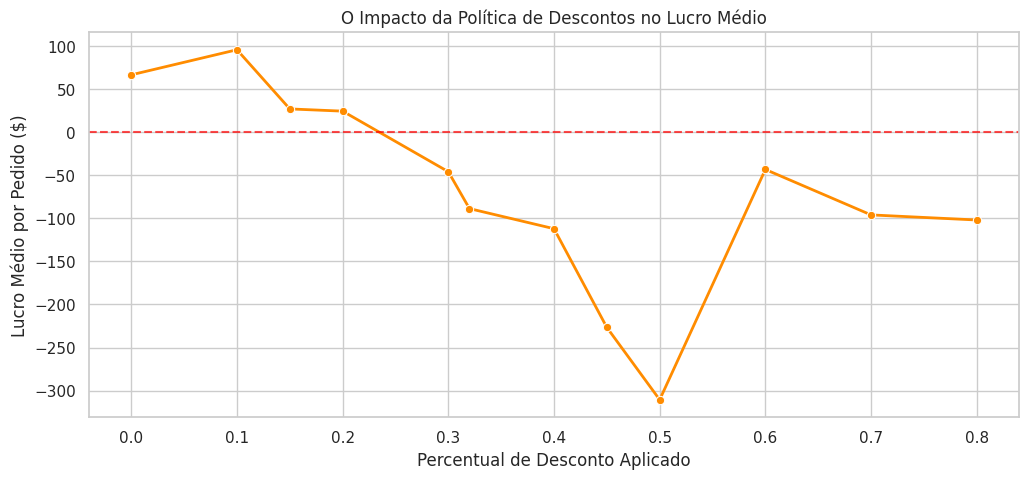

In [51]:
#Impacto dos Descontos na Rentabilidade
analise_desconto = df.groupby('desconto')['lucro'].mean().reset_index()

sns.lineplot(data=analise_desconto, x='desconto', y='lucro', marker='o', color='darkorange', linewidth=2)
plt.axhline(0, color='red', linestyle='--', alpha=0.7) # Linha que divide lucro de prejuízo

plt.title('O Impacto da Política de Descontos no Lucro Médio')
plt.xlabel('Percentual de Desconto Aplicado')
plt.ylabel('Lucro Médio por Pedido ($)')
plt.show()

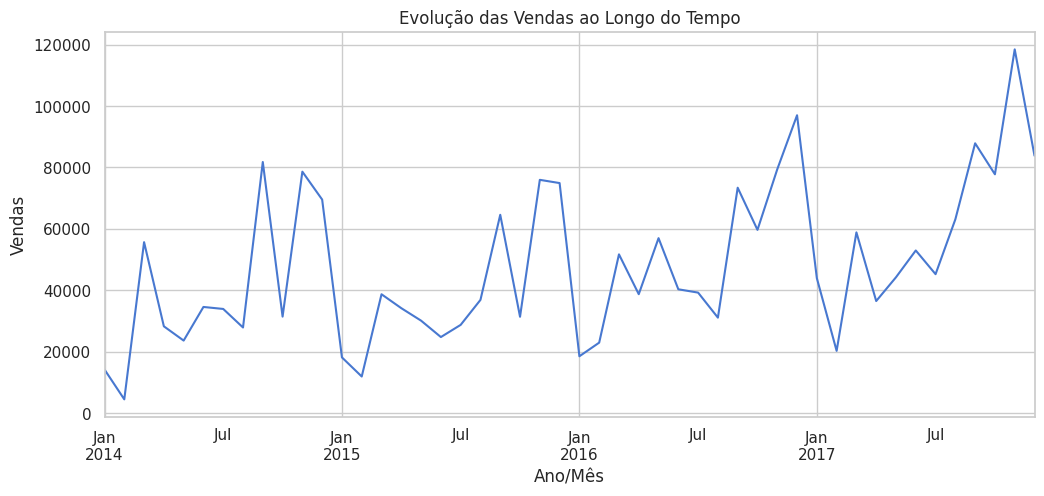

Conclusão: A análise temporal permite identificar períodos de crescimento ou queda nas vendas, além de possíveis sazonalidades no comportamento dos clientes.


In [52]:
#Evolução temporal das vendas

#Criando coluna de mês e ano
df['ano_mes'] = df['data_pedido'].dt.to_period('M')

#Agrupando vendas por mês
vendas_mes = df.groupby('ano_mes')['vendas'].sum()

#Gráfico temporal de evolução das vendas
vendas_mes.plot()

plt.title('Evolução das Vendas ao Longo do Tempo')
plt.xlabel('Ano/Mês')
plt.ylabel('Vendas')

plt.show()
print('Conclusão: A análise temporal permite identificar períodos de crescimento ou queda nas vendas, além de possíveis sazonalidades no comportamento dos clientes.')

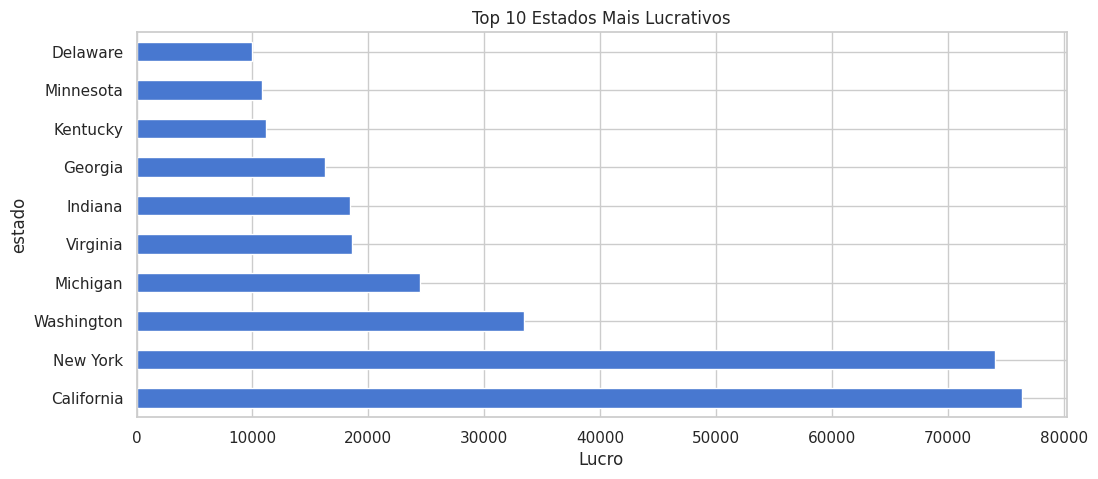

In [53]:
#Top 10 estados mais lucrativos

estado_lucro = (
    df.groupby('estado')['lucro']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

estado_lucro.plot(kind='barh')

plt.title('Top 10 Estados Mais Lucrativos')
plt.xlabel('Lucro')

plt.show()

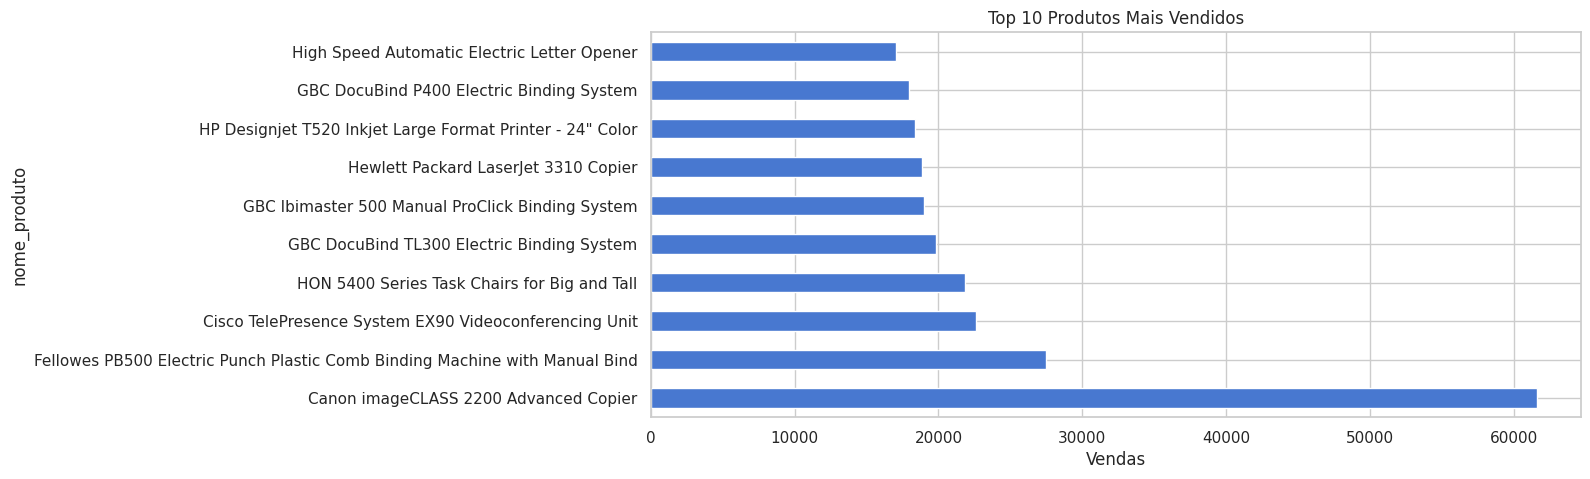

In [54]:
#Produtos mais vendidos

top_produtos = (
    df.groupby('nome_produto')['vendas']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_produtos.plot(kind='barh')

plt.title('Top 10 Produtos Mais Vendidos')
plt.xlabel('Vendas')

plt.show()

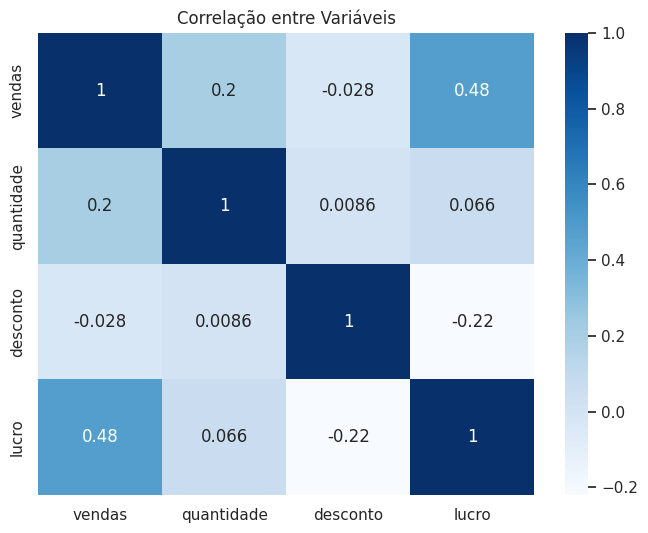

In [55]:
#Mapa de Relação entre Variáveis
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['vendas', 'quantidade', 'desconto', 'lucro']].corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Correlação entre Variáveis')

plt.show()

In [56]:
#Principais indicadores do projeto
total_vendas = df['vendas'].sum()

lucro_total = df['lucro'].sum()

ticket_medio = df['vendas'].mean()

total_pedidos = df['id_pedido'].nunique()

margem_lucro = (
    df['lucro'].sum() / df['vendas'].sum()
) * 100

print(f'Total de Vendas: {total_vendas:.2f}')

print(f'Lucro Total: {lucro_total:.2f}')

print(f'Ticket Médio: {ticket_medio:.2f}')

print(f'Total de Pedidos: {total_pedidos}')

print(f'Margem de Lucro: {margem_lucro:.2f}%')

Total de Vendas: 2297200.86
Lucro Total: 286397.02
Ticket Médio: 229.86
Total de Pedidos: 5009
Margem de Lucro: 12.47%


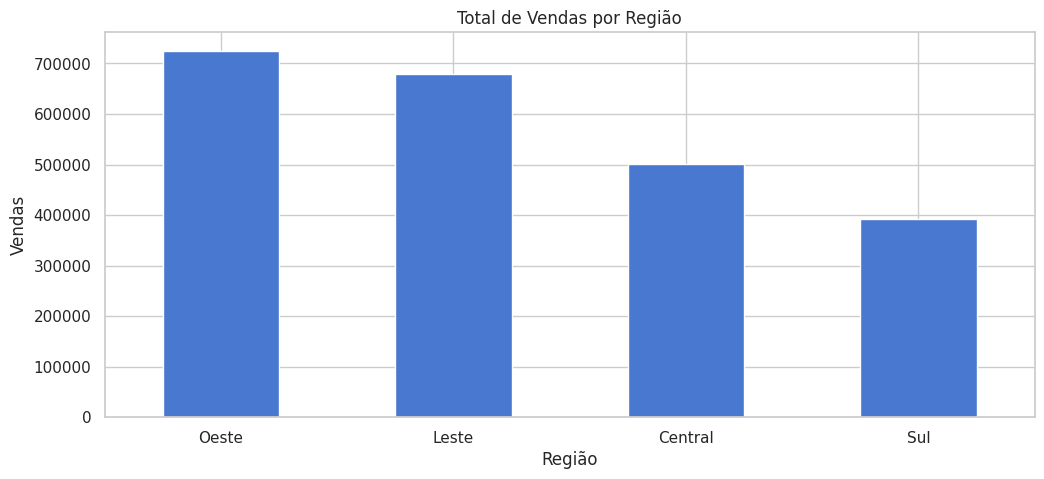

Conclusão: Essa análise permite identificar quais regiões possuem maior participação nas vendas da empresa.


In [57]:
# Total de vendas por região
vendas_regiao = df.groupby('regiao')['vendas'].sum().sort_values(ascending=False)

vendas_regiao.plot(kind='bar')

plt.title('Total de Vendas por Região')
plt.xlabel('Região')
plt.ylabel('Vendas')
plt.xticks(rotation=0)
plt.show()

print('Conclusão: Essa análise permite identificar quais regiões possuem maior participação nas vendas da empresa.')

In [58]:
df.to_csv('superstore_dashboard.csv', index=False)

margem_categoria = (
    df.groupby('categoria')[['vendas', 'lucro']]
    .sum()
)

margem_categoria['margem_lucro'] = (
    margem_categoria['lucro'] / margem_categoria['vendas']
) * 100

print(margem_categoria)

print('Conclusão: A margem de lucro ajuda a identificar quais categorias possuem melhor rentabilidade proporcional.')

                              vendas        lucro  margem_lucro
categoria                                                      
Materiais de Escritório  719047.0320  122490.8008     17.035158
Móveis                   741999.7953   18451.2728      2.486695
Tecnologia               836154.0330  145454.9481     17.395712
Conclusão: A margem de lucro ajuda a identificar quais categorias possuem melhor rentabilidade proporcional.


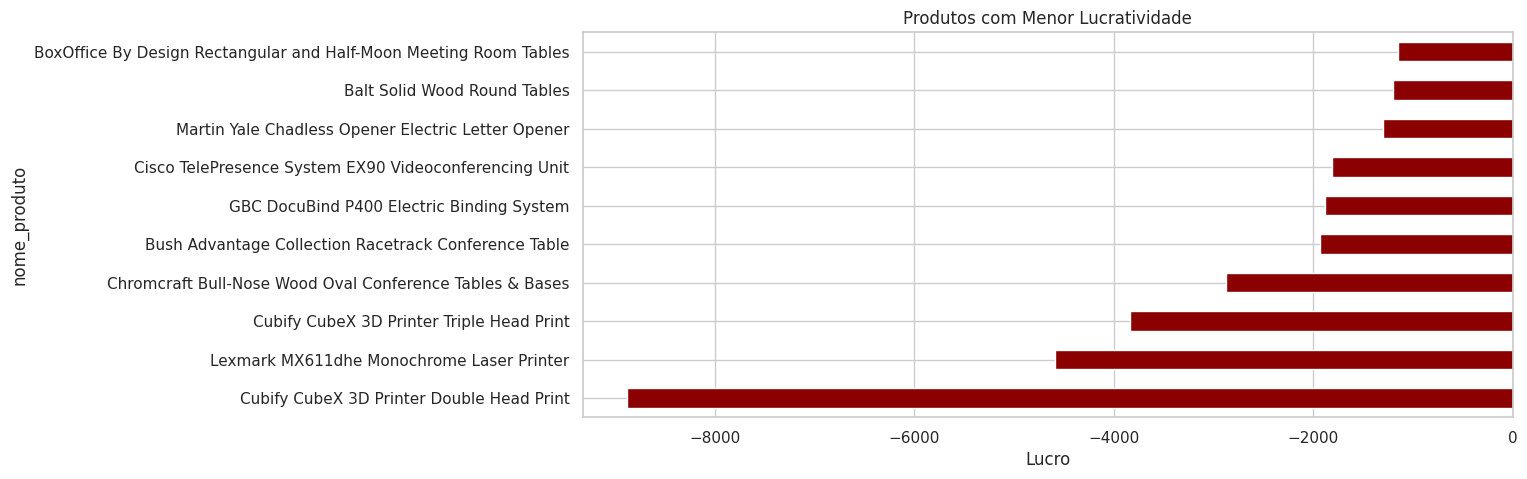

Conclusão: Alguns produtos apresentam baixa lucratividade ou prejuízo, podendo exigir revisão de preços, descontos ou estratégia comercial.


In [59]:
produtos_prejuizo = (
    df.groupby('nome_produto')['lucro']
    .sum()
    .sort_values()
    .head(10)
)

produtos_prejuizo.plot(kind='barh', color='darkred')

plt.title('Produtos com Menor Lucratividade')
plt.xlabel('Lucro')

plt.show()

print('Conclusão: Alguns produtos apresentam baixa lucratividade ou prejuízo, podendo exigir revisão de preços, descontos ou estratégia comercial.')

In [60]:
# Calculando tempo de envio

df['tempo_envio'] = (
    df['data_envio'] - df['data_pedido']
).dt.days

media_envio = df['tempo_envio'].mean()

print(f'Tempo médio de envio: {media_envio:.2f} dias')

print('Conclusão: O tempo médio de envio permite avaliar a eficiência logística da empresa.')

Tempo médio de envio: 3.96 dias
Conclusão: O tempo médio de envio permite avaliar a eficiência logística da empresa.


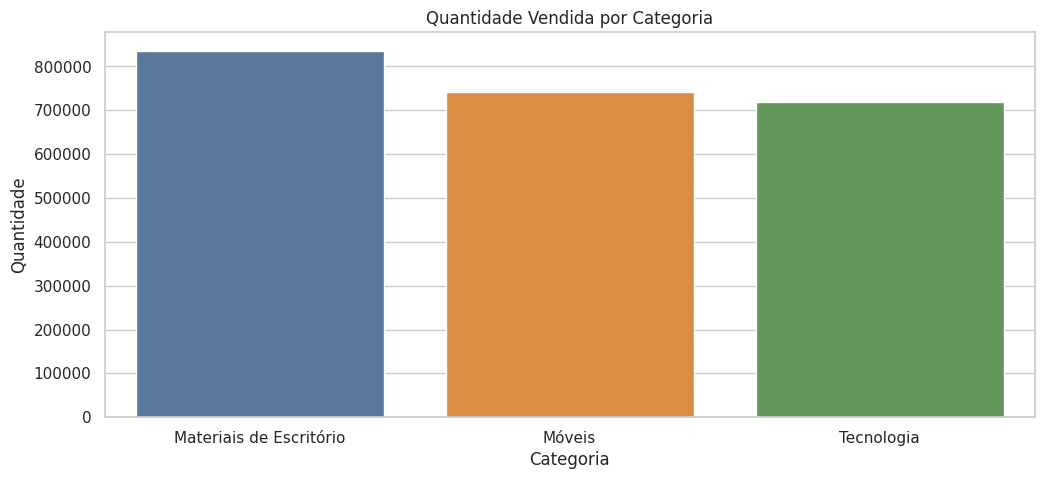

Conclusão: Essa análise demonstra quais categorias possuem maior volume de itens vendidos.


In [61]:
#Análise da Quantidade Vendida
quantidade_categoria = (
    df.groupby('categoria')['quantidade']
    .sum()
)

quantidade_categoria.plot(kind='bar', color='orange')
sns.barplot(x=categoria_vendas.index, y=categoria_vendas.values, palette=['#4e79a7', '#f28e2b', '#59a14f'])
plt.title('Quantidade Vendida por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.show()

print('Conclusão: Essa análise demonstra quais categorias possuem maior volume de itens vendidos.')

In [62]:
#Criando coluna de tempo de entrega
df['tempo_entrega'] = (
    df['data_envio'] - df['data_pedido']
).dt.days

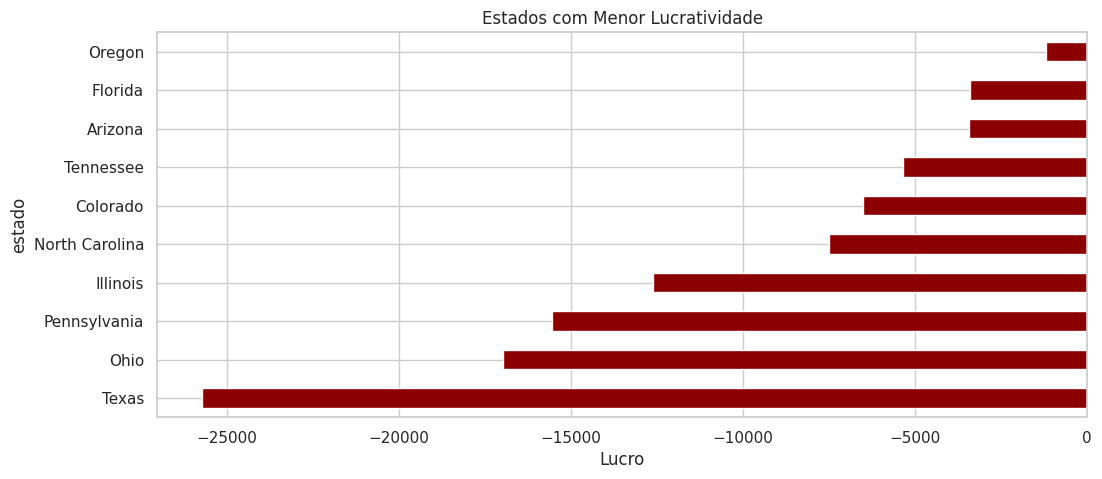

Conclusão: Alguns estados apresentam baixa lucratividade, o que pode indicar altos custos operacionais ou excesso de descontos.


In [63]:
#Estados que geram prejuízo
estados_prejuizo = (
    df.groupby('estado')['lucro']
    .sum()
    .sort_values()
    .head(10)
)

estados_prejuizo.plot(kind='barh', color='darkred')

plt.title('Estados com Menor Lucratividade')
plt.xlabel('Lucro')

plt.show()

print('Conclusão: Alguns estados apresentam baixa lucratividade, o que pode indicar altos custos operacionais ou excesso de descontos.')

In [64]:
print('CONCLUSÃO FINAL DO PROJETO')
print()
print('A análise dos dados permitiu identificar padrões importantes relacionados às vendas, lucratividade, descontos e comportamento dos clientes.')
print('Foi possível observar que determinadas categorias possuem alto faturamento, enquanto outras apresentam melhor margem de lucro.')
print('Também foi identificado que descontos elevados podem impactar negativamente a rentabilidade da empresa.')
print('Além disso, a análise regional e temporal ajudou a compreender diferenças de desempenho entre regiões e períodos do ano.')
print('Essas informações podem auxiliar na tomada de decisões estratégicas, contribuindo para melhoria dos resultados comerciais da empresa.')

CONCLUSÃO FINAL DO PROJETO

A análise dos dados permitiu identificar padrões importantes relacionados às vendas, lucratividade, descontos e comportamento dos clientes.
Foi possível observar que determinadas categorias possuem alto faturamento, enquanto outras apresentam melhor margem de lucro.
Também foi identificado que descontos elevados podem impactar negativamente a rentabilidade da empresa.
Além disso, a análise regional e temporal ajudou a compreender diferenças de desempenho entre regiões e períodos do ano.
Essas informações podem auxiliar na tomada de decisões estratégicas, contribuindo para melhoria dos resultados comerciais da empresa.


In [67]:
from google.colab import files
files.download('superstore_camila_gomes_dos_santos.csv') # Alterado para um nome de arquivo existente

FileNotFoundError: Cannot find file: superstore_camila_gomes_dos_santos.csv

In [68]:
df.to_csv('superstore_camila_gomes_dos_santos.csv', index=False)
print('Arquivo salvo como superstore_camila_gomes_dos_santos.csv')

Arquivo salvo como superstore_camila_gomes_dos_santos.csv
